In [10]:
import torch
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

pt_files = glob.glob("*.pt")
all_features = []

for f in pt_files:
    data = torch.load(f)
    # upper_body = feats[:, :11, :]
    upper = data['landmarks'][:, :11, :]  # Extract upper body landmarks
    feats = upper.view(data['landmarks'].shape[0], -1) #
    all_features.append(feats.numpy())

X = np.vstack(all_features)
print("Feature shape:", X.shape)


Feature shape: (8133, 22)


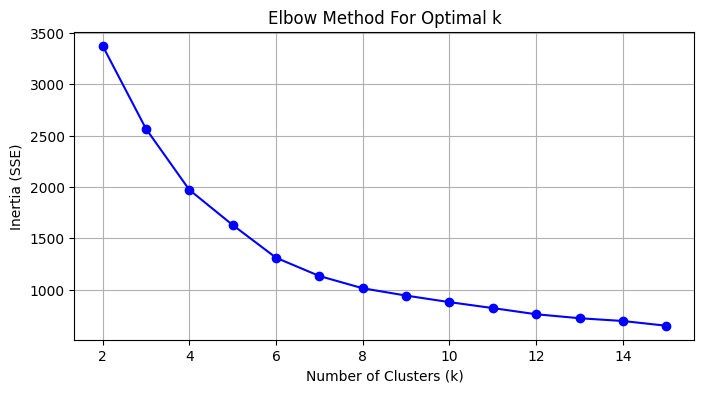

In [24]:
inertias = []
K_range = range(2, 16) #

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

#
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [19]:
# test 6
optimal_k = 3 

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

counts = np.bincount(labels)
for i, c in enumerate(counts):
    print(f"cluster {i}: {c} {c/len(labels)*100:.1f}%")

cluster 0: 11277 69.4%
cluster 1: 2782 17.1%
cluster 2: 2191 13.5%


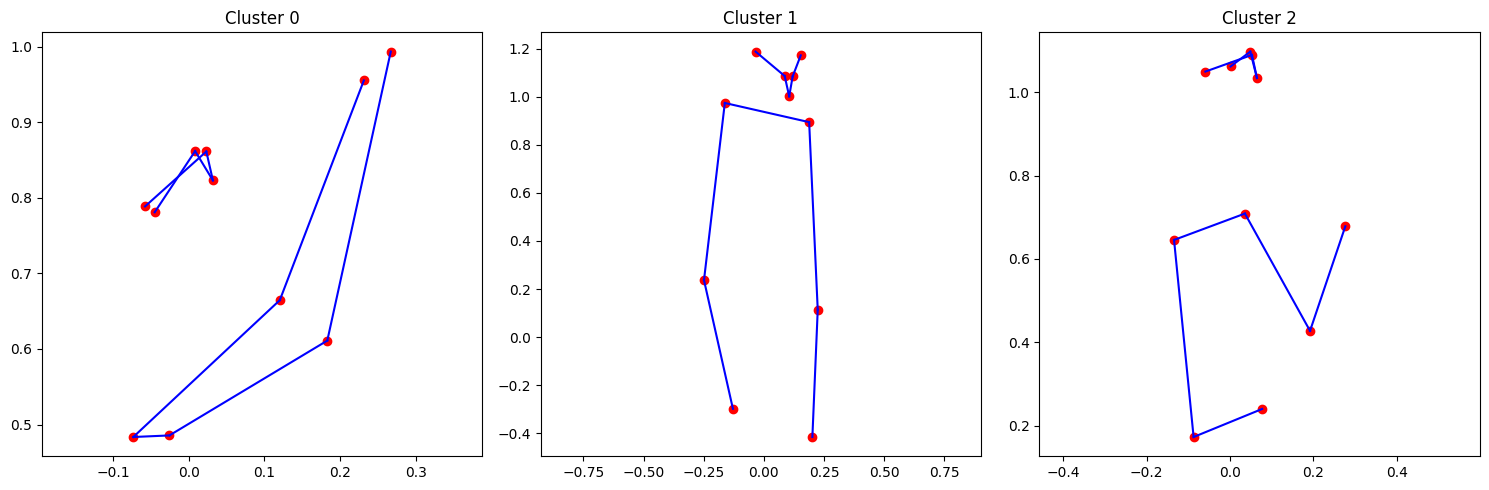

In [20]:
def plot_skeleton(points, title):
    EDGES = [(0, 1), (0, 2), (1, 3), (2, 4), (5, 6), (5, 7), (7, 9), (6, 8), 
             (8, 10)]
    
    pts = points.reshape(11, 2)
    plt.scatter(pts[:, 0], -pts[:, 1], c='red') 
    for edge in EDGES:
        plt.plot([pts[edge[0], 0], pts[edge[1], 0]], 
                 [-pts[edge[0], 1], -pts[edge[1], 1]], 'b-')
    plt.title(title)
    plt.axis('equal')

plt.figure(figsize=(15, 5))
for i in range(optimal_k):
    plt.subplot(1, optimal_k, i+1)
    plot_skeleton(kmeans.cluster_centers_[i], f"Cluster {i}")
plt.tight_layout()
plt.show()

In [29]:

def plot_parallel_behavior_heatmap(data_path, n_clusters=5, target_steps=100):
    """
    """

    pt_files = sorted(glob.glob(os.path.join(data_path, "*.pt")))
    if not pt_files:
        print("no such files exist in the specified path.")
        return

    all_video_features = [] 
    video_names = []
    global_X = []           # data pool for global clustering

    for pf in pt_files:
        data = torch.load(pf)
        # [Frames, 17, 2] -> [Frames, 34]
        # feats = data['landmarks'].view(data['landmarks'].shape[0], -1).numpy()
        feats = data['landmarks']
        upper_body = feats[:, :11, :]
        flattened_feats = upper_body.reshape(upper_body.shape[0], -1).numpy()

        all_video_features.append(flattened_feats)
        global_X.append(flattened_feats)
        video_names.append(os.path.basename(pf).replace(".pt", ""))

    # 2. traing KMeans on the global data pool
    print(f"processing {len(pt_files)} videos for global clustering...")
    X_concat = np.vstack(global_X)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(X_concat)

    # 3. transform each video into a Cluster ID sequence, and resample to target_steps length

    parallel_matrix = []

    for feats in all_video_features:

        labels = kmeans.predict(feats)
        

        indices = np.linspace(0, len(labels) - 1, target_steps).astype(int)
        resampled_labels = labels[indices]
        parallel_matrix.append(resampled_labels)

    parallel_matrix = np.array(parallel_matrix)
    plt.figure(figsize=(16, max(6, len(pt_files) * 0.5)))
    

    cmap = plt.get_cmap("tab20", n_clusters)
    
    sns.heatmap(parallel_matrix, 
                cmap=cmap, 
                xticklabels=10, 
                yticklabels=video_names,
                cbar_kws={'label': 'Cluster ID (Pose Type)', 'ticks': range(n_clusters)})

    plt.title("Parallel Action Pattern Analysis (Normalized Progress 0-100%)", fontsize=15)
    plt.xlabel("Task Progress (%)", fontsize=12)
    plt.ylabel("Video Samples / Workers", fontsize=12)

    plt.xticks(np.linspace(0, target_steps, 21), [f"{i*5}%" for i in range(21)])
    
    plt.tight_layout()
    plt.show()

    return kmeans, parallel_matrix

processing 3 videos for global clustering...


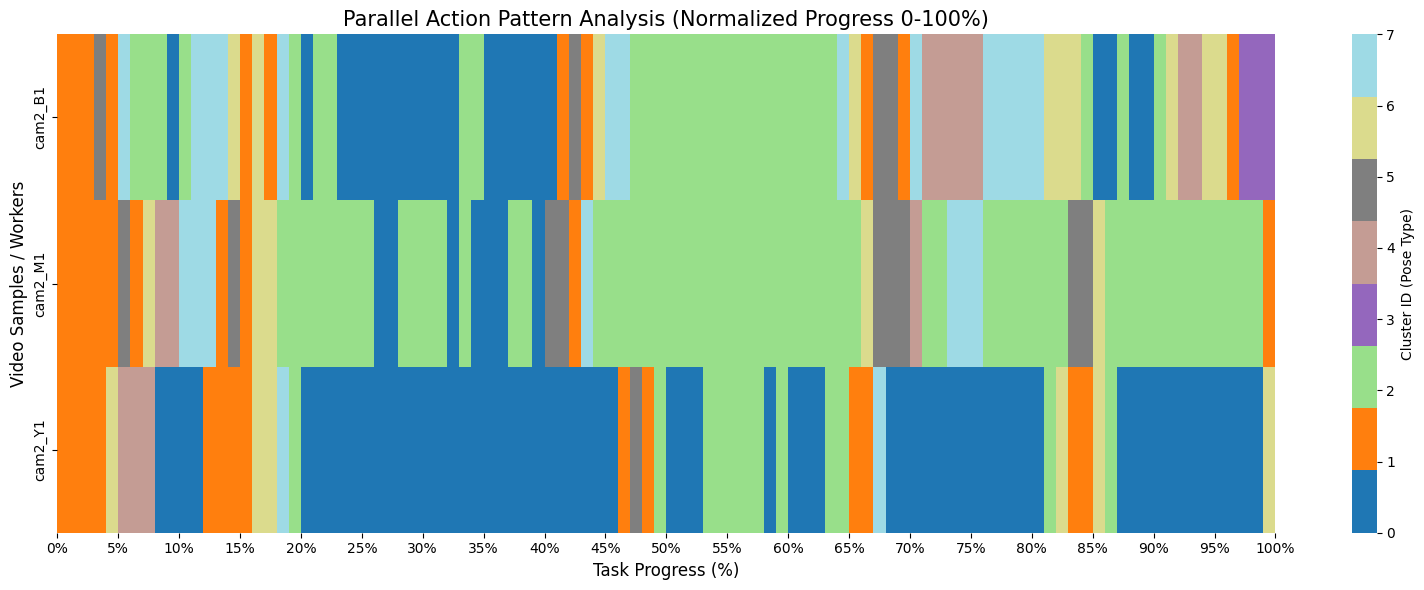

In [30]:
kmeans_model, matrix = plot_parallel_behavior_heatmap("", n_clusters=8,target_steps=100)